<a href="https://colab.research.google.com/github/camendozac/pruebaPython/blob/main/ProcesamientoLenguajeNatural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A continuación se muestra un programa en Python que implementa un ejemplo sencillo de **Procesamiento de Lenguaje Natural (NLP) no supervisado** utilizando un modelo estadístico basado en n-gramas (bigramas). Este modelo aprende patrones de un conjunto de textos sin etiquetas y luego sugiere la siguiente palabra, simulando el funcionamiento básico del autocompletado de los mensajes de texto.

Un modelo de **bigramas** es un tipo de modelo de lenguaje probabilístico que predice la probabilidad de una palabra basándose únicamente en la palabra que la precede. Pertenece a la familia de los N-gramas (n = 2) y utiliza la hipótesis de Markov, simplificando las dependencias del lenguaje.

¿Cómo funciona?

Se calcula mediante la probabilidad condicional de una palabra Wi dado que la palabra anterior es Wi-1. La ecuación estándar se calcula utilizando la Estimación de Máxima Verosimilitud (MLE) dividiendo la frecuencia del par entre la frecuencia de la primera palabra:

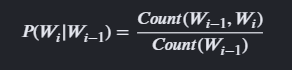

Ejemplo práctico:
Si en tu base de datos aparece el par "hola mundo" 10 veces y la palabra "hola" sola aparece 20 veces:
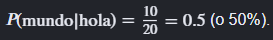

**Usos principales**
* Predicción de texto: Sugerencias en teclados móviles y autocompletado.
* Corrección ortográfica: Identificación de combinaciones de palabras poco probables.
* Reconocimiento de voz: Mejora en la decodificación de audio a texto.
**Explicación del algoritmo**
* Entrada sin etiquetar: El programa utiliza un conjunto de oraciones sin categorías ni etiquetas.
* Preprocesamiento: Convierte el texto a minúsculas y elimina caracteres especiales.
* Aprendizaje estadístico: Construye un modelo de bigramas, contabilizando cuántas veces una palabra es seguida por otra.
* Predicción: Cuando el usuario ingresa una palabra, el sistema devuelve las palabras que históricamente la siguen con mayor frecuencia.
* Aprendizaje no supervisado: No existe una variable objetivo; el modelo descubre los patrones únicamente a partir de las frecuencias de coocurrencia en el corpus.

In [8]:
from collections import defaultdict, Counter
import re

# ==========================================
# Base de datos (texto sin etiquetar)
# ==========================================

corpus = [
    "el procesamiento de lenguaje natural es una rama de la inteligencia artificial",
    "la inteligencia artificial aprende patrones a partir de los datos",
    "el procesamiento de datos permite descubrir conocimiento",
    "el aprendizaje automatico mejora con grandes cantidades de datos",
    "la mineria de datos analiza grandes volumenes de informacion",
    "el procesamiento de lenguaje natural utiliza modelos estadisticos",
    "los modelos de lenguaje predicen la siguiente palabra",
    "el analisis de datos ayuda en la toma de decisiones",
    "la inteligencia artificial mejora la experiencia del usuario",
    "el procesamiento de lenguaje natural facilita el autocompletado de mensajes"
]

# ==========================================
# Función para limpiar texto
# ==========================================

def limpiar(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)
    return texto.split()

# ==========================================
# Construcción del modelo Bigrama
# ==========================================

modelo = defaultdict(Counter)

for frase in corpus:
    palabras = limpiar(frase)

    for i in range(len(palabras)-1):
        palabra_actual = palabras[i]
        siguiente_palabra = palabras[i+1]

        modelo[palabra_actual][siguiente_palabra] += 1

# ==========================================
# Función de autocompletar
# ==========================================

def autocompletar(palabra):
    palabra = palabra.lower()

    if palabra not in modelo:
        return "No existen sugerencias."

    sugerencias = modelo[palabra].most_common(5)

    return sugerencias

# ==========================================
# Programa principal
# ==========================================

print("="*50)
print(" MODELO NLP NO SUPERVISADO - AUTOCOMPLETADO ")
print("="*50)

while True:

    entrada = input("\nIngrese una palabra (o salir): ")

    if entrada.lower() == "salir":
        break

    resultado = autocompletar(entrada)

    if isinstance(resultado, str):
        print(resultado)
    else:
        print("\nPalabras sugeridas:")

        for palabra, frecuencia in resultado:
            print(f"- {palabra} (Frecuencia: {frecuencia})")

 MODELO NLP NO SUPERVISADO - AUTOCOMPLETADO 

Ingrese una palabra (o salir): salir


BERT (por sus siglas en inglés, Bidirectional Encoder Representations from Transformers) es un modelo de inteligencia artificial de Google diseñado para el Procesamiento del Lenguaje Natural (PLN). Su función principal es entender el contexto exacto y el significado de las palabras leyendo el texto de forma bidireccional (hacia adelante y hacia atrás al mismo tiempo).

In [1]:
from transformers import pipeline

# ======================================================
# Cargar modelo BERT en español
# ======================================================

modelo = pipeline(
    task="fill-mask",
    model="dccuchile/bert-base-spanish-wwm-cased"
)

print("="*60)
print(" AUTOCOMPLETADO UTILIZANDO BERT ")
print("="*60)

while True:

    print("\nEscriba una oración utilizando [MASK]")
    print("Ejemplo:")
    print("El procesamiento de lenguaje [MASK] utiliza inteligencia artificial")

    texto = input("\nIngrese la oración (o salir): ")

    if texto.lower() == "salir":
        break

    try:

        resultado = modelo(texto)

        print("\nSugerencias:\n")

        for i, prediccion in enumerate(resultado, start=1):

            palabra = prediccion["token_str"]
            probabilidad = prediccion["score"]

            print(f"{i}. {palabra:20} Probabilidad: {probabilidad:.4f}")

    except Exception as e:
        print("\nError:", e)
        print("Recuerde incluir exactamente un token [MASK].")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

 AUTOCOMPLETADO UTILIZANDO BERT 

Escriba una oración utilizando [MASK]
Ejemplo:
El procesamiento de lenguaje [MASK] utiliza inteligencia artificial

Ingrese la oración (o salir): sallir

Error: No mask_token ([MASK]) found on the input
Recuerde incluir exactamente un token [MASK].

Escriba una oración utilizando [MASK]
Ejemplo:
El procesamiento de lenguaje [MASK] utiliza inteligencia artificial

Ingrese la oración (o salir): salir


In [2]:
from transformers import pipeline

# ==============================================
# Modelo BERT en español
# ==============================================

modelo = pipeline(
    "fill-mask",
    model="dccuchile/bert-base-spanish-wwm-cased"
)

print("="*70)
print("AUTOCOMPLETADO CON BERT")
print("="*70)

while True:

    texto = input("\nIngrese una oración (o salir): ")

    if texto.lower() == "salir":
        break

    palabra = input("¿Qué palabra desea ocultar?: ")

    # Buscar la palabra
    if palabra not in texto:

        print("\nLa palabra no existe en la oración.")
        continue

    # Reemplazar únicamente la primera aparición
    texto_mask = texto.replace(palabra, "[MASK]", 1)

    print("\nOración enviada a BERT:")
    print(texto_mask)

    print("\nPredicciones:\n")

    resultados = modelo(texto_mask)

    for i, r in enumerate(resultados, 1):

        print(f"{i}. {r['token_str']:20} Probabilidad: {r['score']:.4f}")

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

AUTOCOMPLETADO CON BERT

Ingrese una oración (o salir): La constitución política del Perú esta cambiando por malos elementos del congreso
¿Qué palabra desea ocultar?: Perú

Oración enviada a BERT:
La constitución política del [MASK] esta cambiando por malos elementos del congreso

Predicciones:

1. país                 Probabilidad: 0.4583
2. estado               Probabilidad: 0.1295
3. Perú                 Probabilidad: 0.0805
4. Ecuador              Probabilidad: 0.0750
5. Estado               Probabilidad: 0.0382

Ingrese una oración (o salir): salir


In [3]:
from transformers import pipeline

modelo = pipeline(
    "fill-mask",
    model="dccuchile/bert-base-spanish-wwm-cased"
)

while True:

    texto = input("\nEscriba una oración usando ___ (o salir): ")

    if texto.lower() == "salir":
        break

    if "___" not in texto:
        print("Debe escribir ___ donde desea la predicción.")
        continue

    texto = texto.replace("___", "[MASK]")

    resultados = modelo(texto)

    print("\nSugerencias:\n")

    for r in resultados:
        print(f"{r['token_str']:20} {r['score']:.4f}")

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]


Escriba una oración usando ___ (o salir): La constitución política del Perú esta cambiando por malos elementos del congreso.
Debe escribir ___ donde desea la predicción.

Escriba una oración usando ___ (o salir): La constitución política del Perú esta cambiando por ___ elementos del congreso

Sugerencias:

los                  0.6564
algunos              0.0335
nuevos               0.0259
otros                0.0232
dos                  0.0202

Escriba una oración usando ___ (o salir): La constitución política del Perú esta cambiando por ___ elementos del congreso

Sugerencias:

los                  0.6564
algunos              0.0335
nuevos               0.0259
otros                0.0232
dos                  0.0202

Escriba una oración usando ___ (o salir): salir
